In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [3]:
data = load_breast_cancer()
df = pd.DataFrame(data=data['data'],columns = data['feature_names'])
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X = df.copy()
y = data['target']
X_train , X_test, y_train,y_test = train_test_split(X,y,test_size = 0.33)

In [6]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf = clf.fit(X_train , y_train)

In [7]:
clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [8]:
df.shape

(569, 30)

In [9]:
pred = clf.predict(X_test)

In [10]:
pred

array([1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0])

In [11]:
from sklearn.metrics import accuracy_score

In [12]:
accuracy_score(y_test,pred)

0.9468085106382979

In [13]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test , pred ,labels = [0,1])

array([[ 68,  10],
       [  0, 110]])

In [14]:
## TP : 57 (CANCER-> CANCER) TN: 115 , FN : 9(9 had cancer but model predicts no cancer) 
## FP (7 had no cancer but model showed cancer)

In [15]:
from sklearn.metrics import precision_score
precision_score(y_test , pred)

0.9166666666666666

In [16]:
from sklearn.metrics import recall_score
precision_score(y_test , pred)

0.9166666666666666

In [17]:
clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [18]:
feature_name = X.columns

In [19]:
feature_name

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [ ]:
feature_importance = pd.DataFrame(clf.feature_importances_,index = feature_name,index = feature_name).sort_values(feature_importance

In [21]:
feature_importance = pd.DataFrame({
    'Feature': feature_name,
    'Importance': clf.feature_importances_
})


feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

                    Feature  Importance
22          worst perimeter    0.695927
27     worst concave points    0.093304
1              mean texture    0.080490
23               worst area    0.031449
7       mean concave points    0.029671
26          worst concavity    0.024967
18           symmetry error    0.015348
21            worst texture    0.011511
16          concavity error    0.009867
13               area error    0.007465
17     concave points error    0.000000
24         worst smoothness    0.000000
20             worst radius    0.000000
19  fractal dimension error    0.000000
25        worst compactness    0.000000
28           worst symmetry    0.000000
0               mean radius    0.000000
15        compactness error    0.000000
14         smoothness error    0.000000
12          perimeter error    0.000000
11            texture error    0.000000
10             radius error    0.000000
9    mean fractal dimension    0.000000
8             mean symmetry    0.000000


In [23]:
import pandas as pd

# feature_name is X.columns
feature_name = X.columns

# Create DataFrame with feature importances and set features as index
feature_importance_df = pd.DataFrame(
    clf.feature_importances_,
    index=feature_name,
    columns=['Importance']
)

# Sort by importance descending
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                         Importance
worst perimeter            0.695927
worst concave points       0.093304
mean texture               0.080490
worst area                 0.031449
mean concave points        0.029671
worst concavity            0.024967
symmetry error             0.015348
worst texture              0.011511
concavity error            0.009867
area error                 0.007465
concave points error       0.000000
worst smoothness           0.000000
worst radius               0.000000
fractal dimension error    0.000000
worst compactness          0.000000
worst symmetry             0.000000
mean radius                0.000000
compactness error          0.000000
smoothness error           0.000000
perimeter error            0.000000
texture error              0.000000
radius error               0.000000
mean fractal dimension     0.000000
mean symmetry              0.000000
mean concavity             0.000000
mean compactness           0.000000
mean smoothness            0

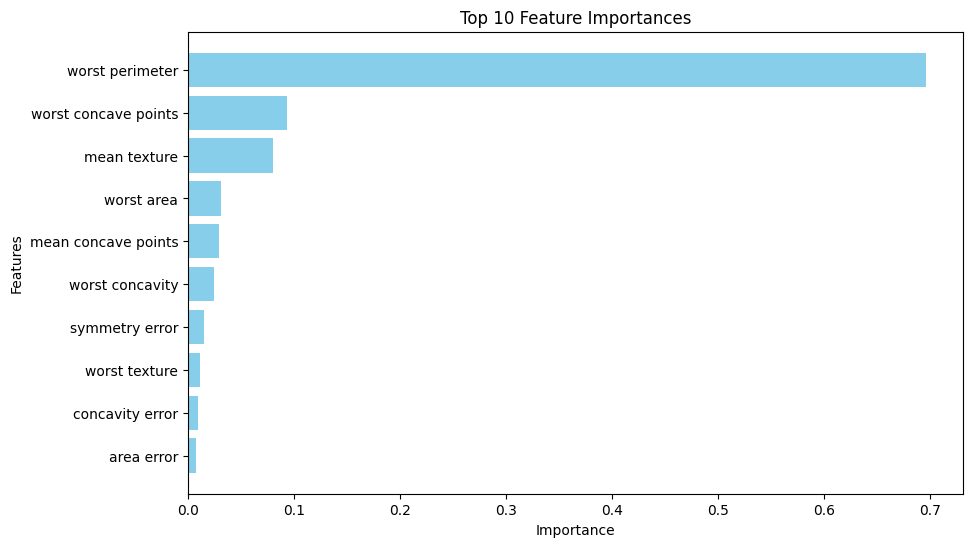

In [25]:
import matplotlib.pyplot as plt

# Take top 10 features
top10 = feature_importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10.index, top10['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()  # Most important feature on top
plt.show()

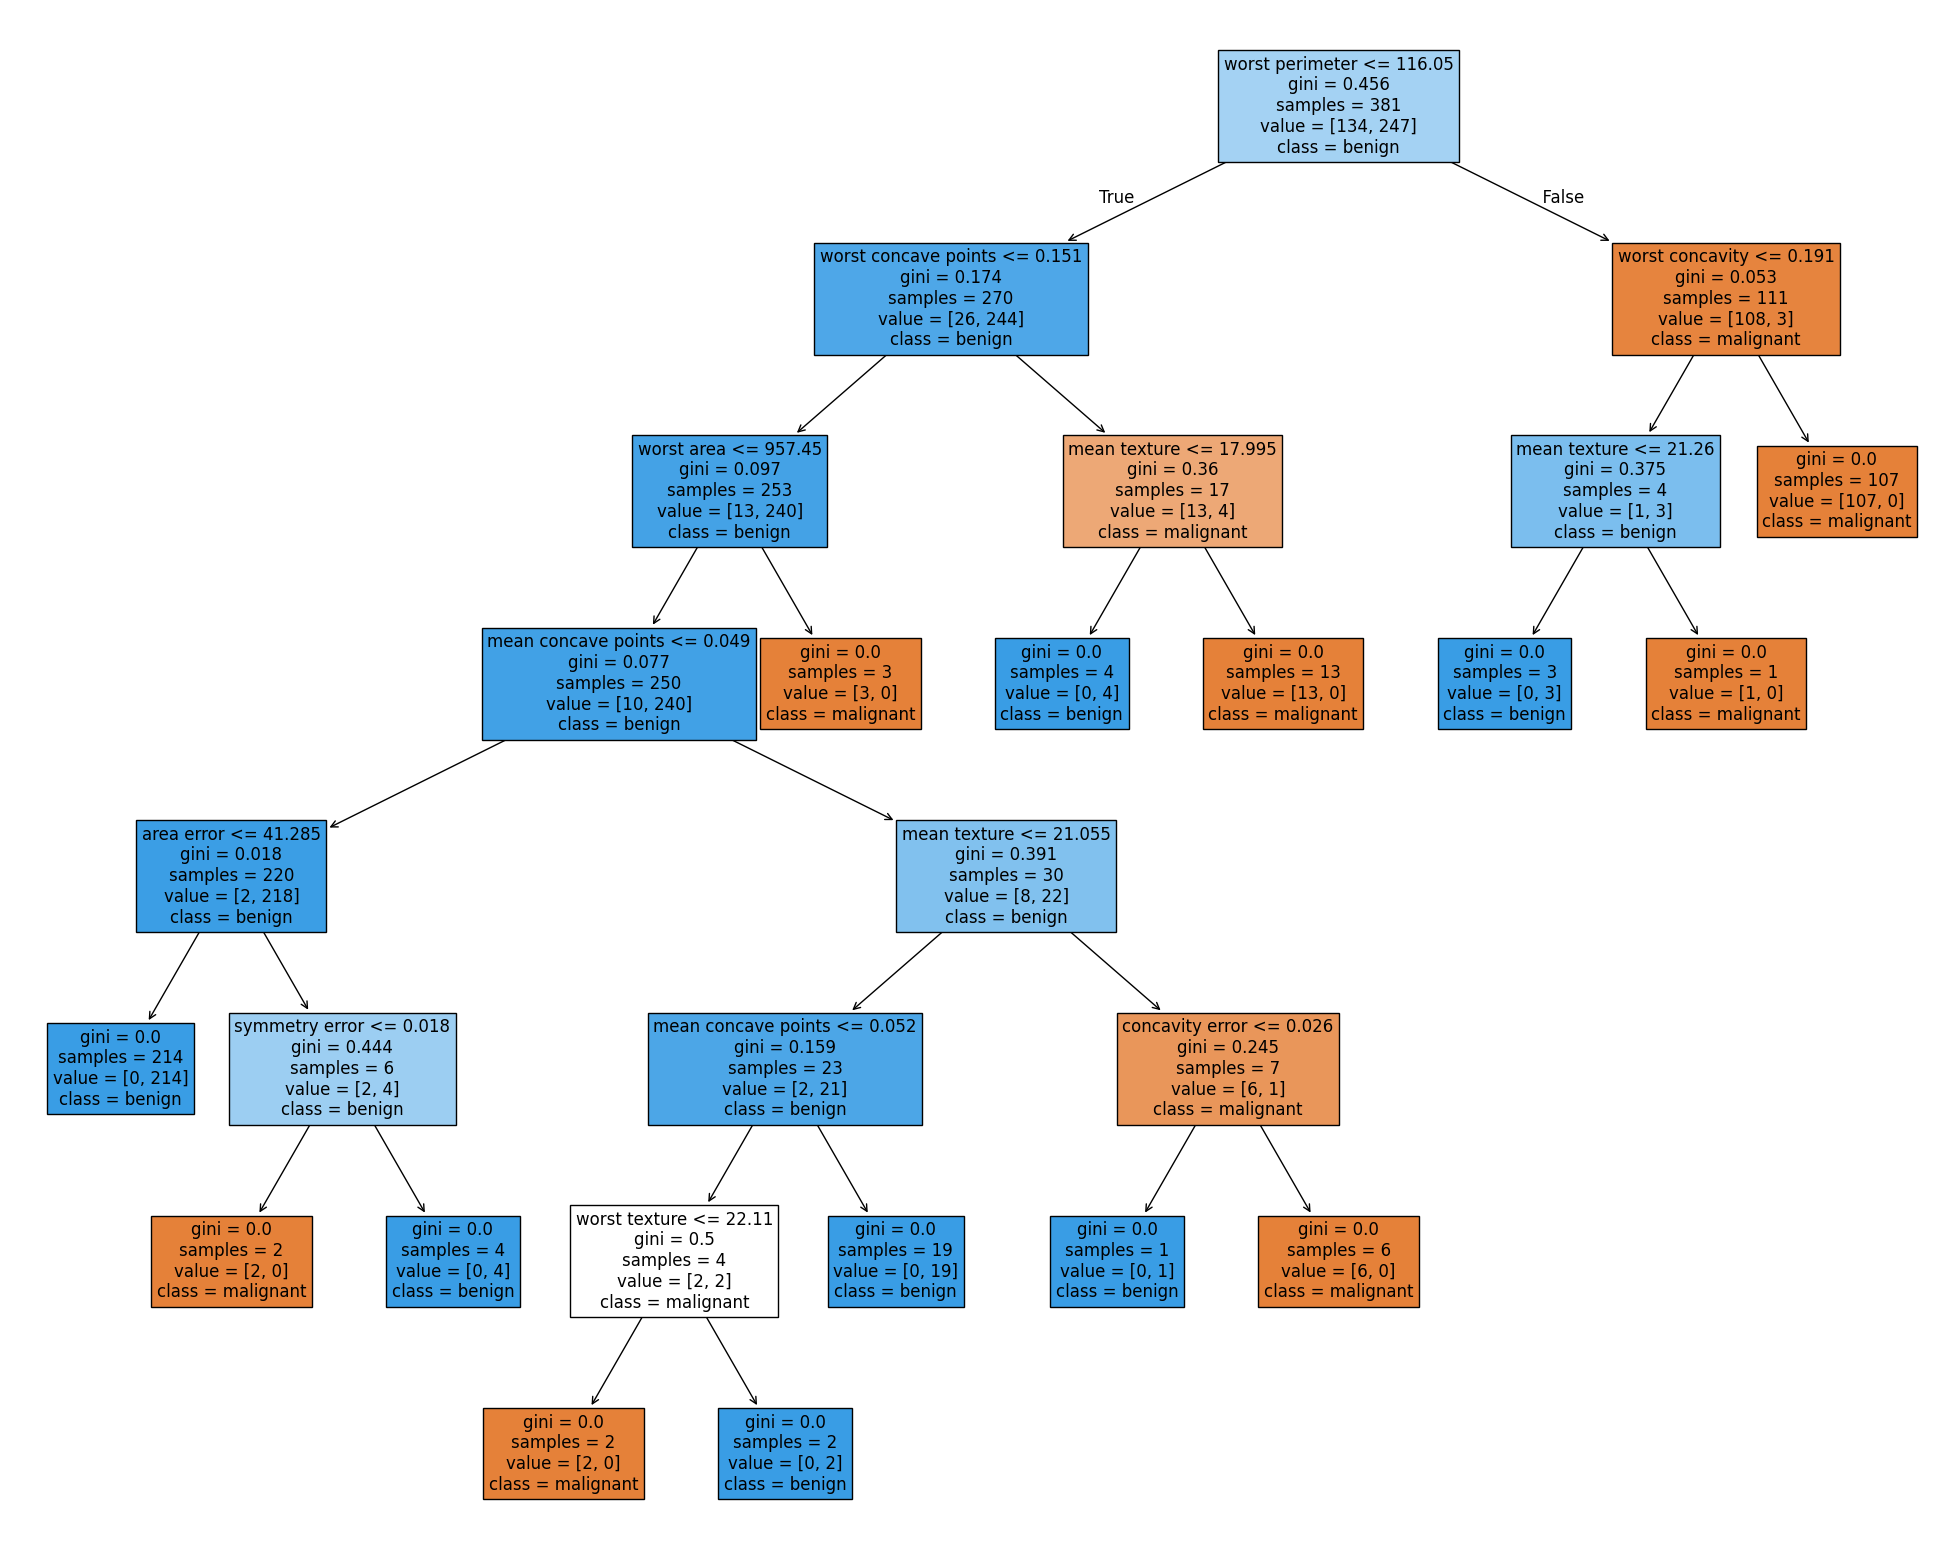

In [29]:
from sklearn import tree
import matplotlib.pyplot as plt


feature_name = X.columns

fig = plt.figure(figsize=(25, 20))

_ = tree.plot_tree(
    clf,
    feature_names=feature_name,            
    class_names=['malignant', 'benign'],
    filled=True,
    fontsize=12
)
plt.show()